In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Функция для оценки модели
def evaluate_model(X, y, model_name=""):
    """
    Оценивает модель линейной регрессии
    
    Parameters:
    X - независимые переменные
    y - зависимая переменная
    model_name - название модели
    
    Returns:
    metrics - словарь с метриками
    """
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Обучение модели
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Прогнозирование
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Расчет метрик
    metrics = {
        'model_name': model_name,
        'n_features': X.shape[1] if len(X.shape) > 1 else 1,
        'coefficients': model.coef_,
        'intercept': model.intercept_,
        'r2_train': r2_score(y_train, y_pred_train),
        'r2_test': r2_score(y_test, y_pred_test),
        'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'mae_train': mean_absolute_error(y_train, y_pred_train),
        'mae_test': mean_absolute_error(y_test, y_pred_test),
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_test': y_pred_test
    }
    
    return metrics

# Функция для проверки мультиколлинеарности
def check_multicollinearity(X):
    """
    Проверяет мультиколлинеарность с помощью VIF
    
    Parameters:
    X - признаки для проверки
    
    Returns:
    vif_data - DataFrame с VIF значениями
    """
    # Добавляем константу
    X_with_const = add_constant(X)
    
    # Расчет VIF
    vif_data = pd.DataFrame()
    vif_data['Признак'] = X_with_const.columns
    vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) 
                       for i in range(X_with_const.shape[1])]
    
    return vif_data

In [3]:
print("="*70)
print("ЧАСТЬ 1: ПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ")
print("="*70)

# Создание искусственных данных для простой линейной регрессии
np.random.seed(42)
n_samples = 100

# Создаем зависимость: y = 2x + 3 + шум
X_simple = np.random.randn(n_samples, 1) * 10
y_simple = 2 * X_simple.flatten() + 3 + np.random.randn(n_samples) * 5

# Преобразуем в DataFrame
df_simple = pd.DataFrame({
    'X': X_simple.flatten(),
    'y': y_simple
})

print("📊 Данные для простой линейной регрессии:")
print(df_simple.head())
print(f"\n📈 Размер датасета: {df_simple.shape}")
print(f"📊 Описательная статистика:")
print(df_simple.describe().round(2))

ЧАСТЬ 1: ПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ
📊 Данные для простой линейной регрессии:
           X          y
0   4.967142   5.857429
1  -1.382643  -1.868513
2   6.476885  14.240198
3  15.230299  29.449211
4  -2.341534  -2.489496

📈 Размер датасета: (100, 2)
📊 Описательная статистика:
            X       y
count  100.00  100.00
mean    -1.04    1.03
std      9.08   18.14
min    -26.20  -48.01
25%     -6.01  -10.34
50%     -1.27    1.26
75%      4.06   12.60
max     18.52   44.02


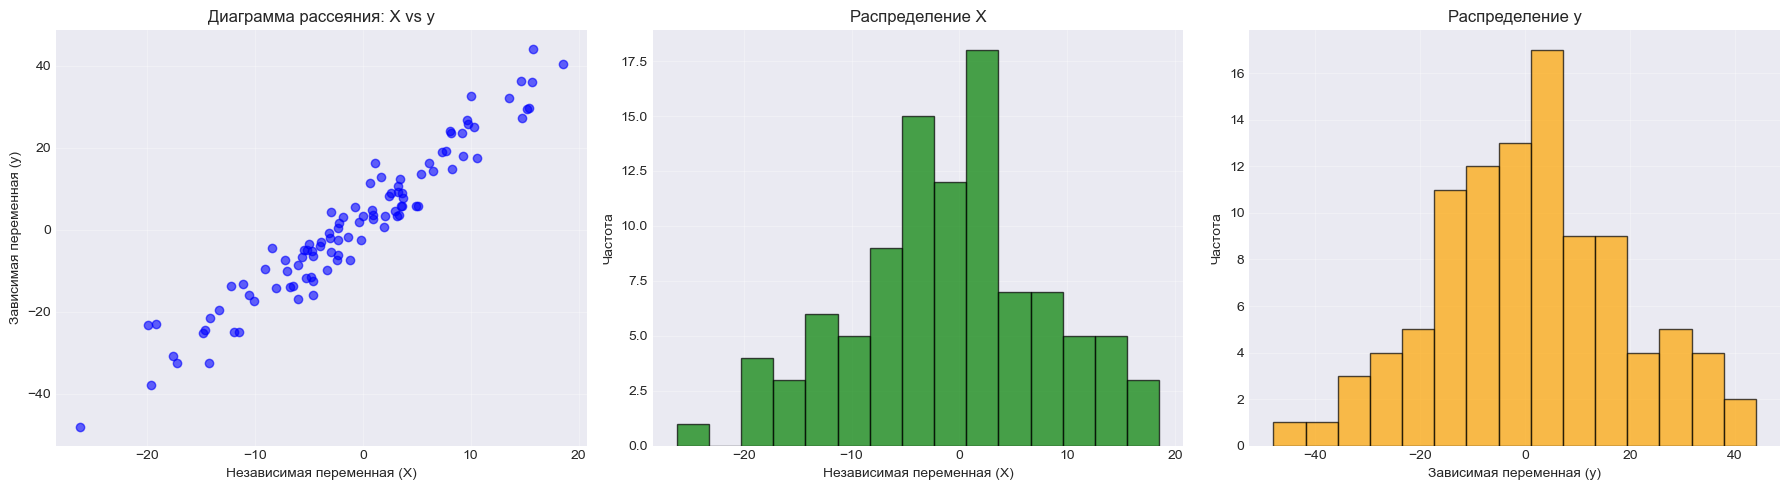

In [4]:
# Визуализация данных для простой линейной регрессии
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Диаграмма рассеяния
axes[0].scatter(df_simple['X'], df_simple['y'], alpha=0.6, color='blue')
axes[0].set_xlabel('Независимая переменная (X)')
axes[0].set_ylabel('Зависимая переменная (y)')
axes[0].set_title('Диаграмма рассеяния: X vs y')
axes[0].grid(True, alpha=0.3)

# 2. Гистограмма X
axes[1].hist(df_simple['X'], bins=15, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Независимая переменная (X)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение X')
axes[1].grid(True, alpha=0.3)

# 3. Гистограмма y
axes[2].hist(df_simple['y'], bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Зависимая переменная (y)')
axes[2].set_ylabel('Частота')
axes[2].set_title('Распределение y')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Подготовка данных
X = df_simple[['X']]  # Независимая переменная
y = df_simple['y']     # Зависимая переменная

# Оценка модели
metrics_simple = evaluate_model(X, y, "Простая линейная регрессия")

print("📊 Параметры модели линейной регрессии:")
print(f"Коэффициент (наклон): {metrics_simple['coefficients'][0]:.4f}")
print(f"Пересечение (intercept): {metrics_simple['intercept']:.4f}")
print(f"Уравнение регрессии: y = {metrics_simple['coefficients'][0]:.4f} * X + {metrics_simple['intercept']:.4f}")

print(f"\n📊 Метрики качества модели:")
print(f"Коэффициент детерминации (R²) на тестовой выборке: {metrics_simple['r2_test']:.4f}")
print(f"Корень из среднеквадратичной ошибки (RMSE): {metrics_simple['rmse_test']:.4f}")
print(f"Средняя абсолютная ошибка (MAE): {metrics_simple['mae_test']:.4f}")

📊 Параметры модели линейной регрессии:
Коэффициент (наклон): 1.9293
Пересечение (intercept): 3.0729
Уравнение регрессии: y = 1.9293 * X + 3.0729

📊 Метрики качества модели:
Коэффициент детерминации (R²) на тестовой выборке: 0.9132
Корень из среднеквадратичной ошибки (RMSE): 4.6713
Средняя абсолютная ошибка (MAE): 3.6936


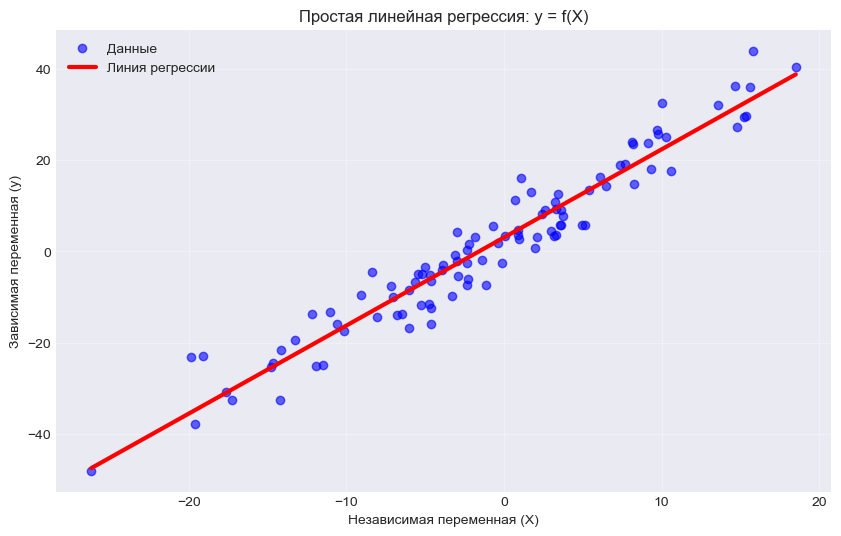

In [6]:
# Визуализация регрессионной линии
plt.figure(figsize=(10, 6))

# Диаграмма рассеяния
plt.scatter(X, y, color='blue', alpha=0.6, label='Данные')

# Линия регрессии
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = metrics_simple['model'].predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=3, label='Линия регрессии')

plt.xlabel('Независимая переменная (X)')
plt.ylabel('Зависимая переменная (y)')
plt.title('Простая линейная регрессия: y = f(X)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

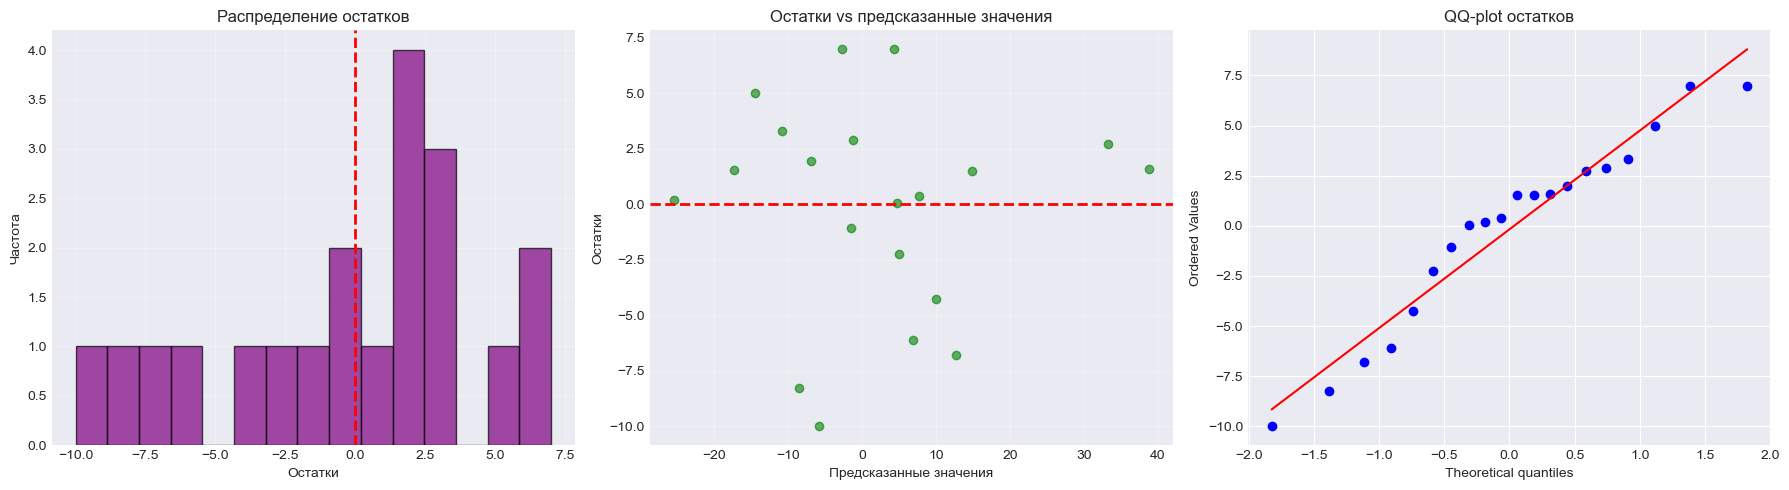

📊 Тест Шапиро-Уилка на нормальность остатков:
Статистика: 0.9437
p-value: 0.2815
✅ Остатки распределены нормально (p-value > 0.05)


In [7]:
# Анализ остатков
residuals = metrics_simple['y_test'] - metrics_simple['y_pred_test']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение остатков
axes[0].hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение остатков')
axes[0].grid(True, alpha=0.3)

# 2. Остатки vs предсказанные значения
axes[1].scatter(metrics_simple['y_pred_test'], residuals, alpha=0.6, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Остатки vs предсказанные значения')
axes[1].grid(True, alpha=0.3)

# 3. QQ-plot для проверки нормальности остатков
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('QQ-plot остатков')

plt.tight_layout()
plt.show()

# Проверка нормальности остатков статистическим тестом
shapiro_test = stats.shapiro(residuals)
print("📊 Тест Шапиро-Уилка на нормальность остатков:")
print(f"Статистика: {shapiro_test.statistic:.4f}")
print(f"p-value: {shapiro_test.pvalue:.4f}")
if shapiro_test.pvalue > 0.05:
    print("✅ Остатки распределены нормально (p-value > 0.05)")
else:
    print("❌ Остатки НЕ распределены нормально (p-value ≤ 0.05)")

In [8]:
print("\n" + "="*70)
print("ЧАСТЬ 2: МНОЖЕСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ")
print("="*70)

# Создание искусственных данных для множественной линейной регрессии
np.random.seed(42)
n_samples = 200

# Создаем независимые переменные
TV = np.random.uniform(0, 300, n_samples)  # Реклама на TV
Radio = np.random.uniform(0, 50, n_samples)  # Реклама на радио
Newspaper = np.random.uniform(0, 100, n_samples)  # Реклама в газетах
Social_Media = np.random.uniform(0, 200, n_samples)  # Реклама в соцсетях

# Создаем зависимую переменную (продажи)
# y = 0.05*TV + 0.1*Radio + 0.03*Newspaper + 0.08*Social_Media + 2.5 + шум
Sales = (0.05 * TV + 0.1 * Radio + 0.03 * Newspaper + 
         0.08 * Social_Media + 2.5 + np.random.randn(n_samples) * 2)

# Создаем DataFrame
df_multiple = pd.DataFrame({
    'TV': TV,
    'Radio': Radio,
    'Newspaper': Newspaper,
    'Social_Media': Social_Media,
    'Sales': Sales
})

print("📊 Данные для множественной линейной регрессии:")
print(df_multiple.head())
print(f"\n📈 Размер датасета: {df_multiple.shape}")
print(f"📊 Описательная статистика:")
print(df_multiple.describe().round(2))


ЧАСТЬ 2: МНОЖЕСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ
📊 Данные для множественной линейной регрессии:
           TV      Radio  Newspaper  Social_Media      Sales
0  112.362036  32.101582  10.312387     33.787013  12.759644
1  285.214292   4.206998  90.255291     55.718068  25.289455
2  219.598183   8.081436  50.525237     35.402097  22.400027
3  179.597545  44.927709  82.645747     17.740507  22.562101
4   46.805592  30.321453  32.004960     24.127174  13.949121

📈 Размер датасета: (200, 5)
📊 Описательная статистика:
           TV   Radio  Newspaper  Social_Media   Sales
count  200.00  200.00     200.00        200.00  200.00
mean   145.20   25.22      52.07         95.75   21.49
std     88.47   14.65      30.73         55.77    6.70
min      1.66    0.25       1.08          3.62    3.75
25%     68.57   13.07      25.55         47.19   16.61
50%    148.35   27.08      52.54         93.43   21.86
75%    227.06   37.11      81.11        144.88   26.01
max    296.07   49.53      99.97        197.99  

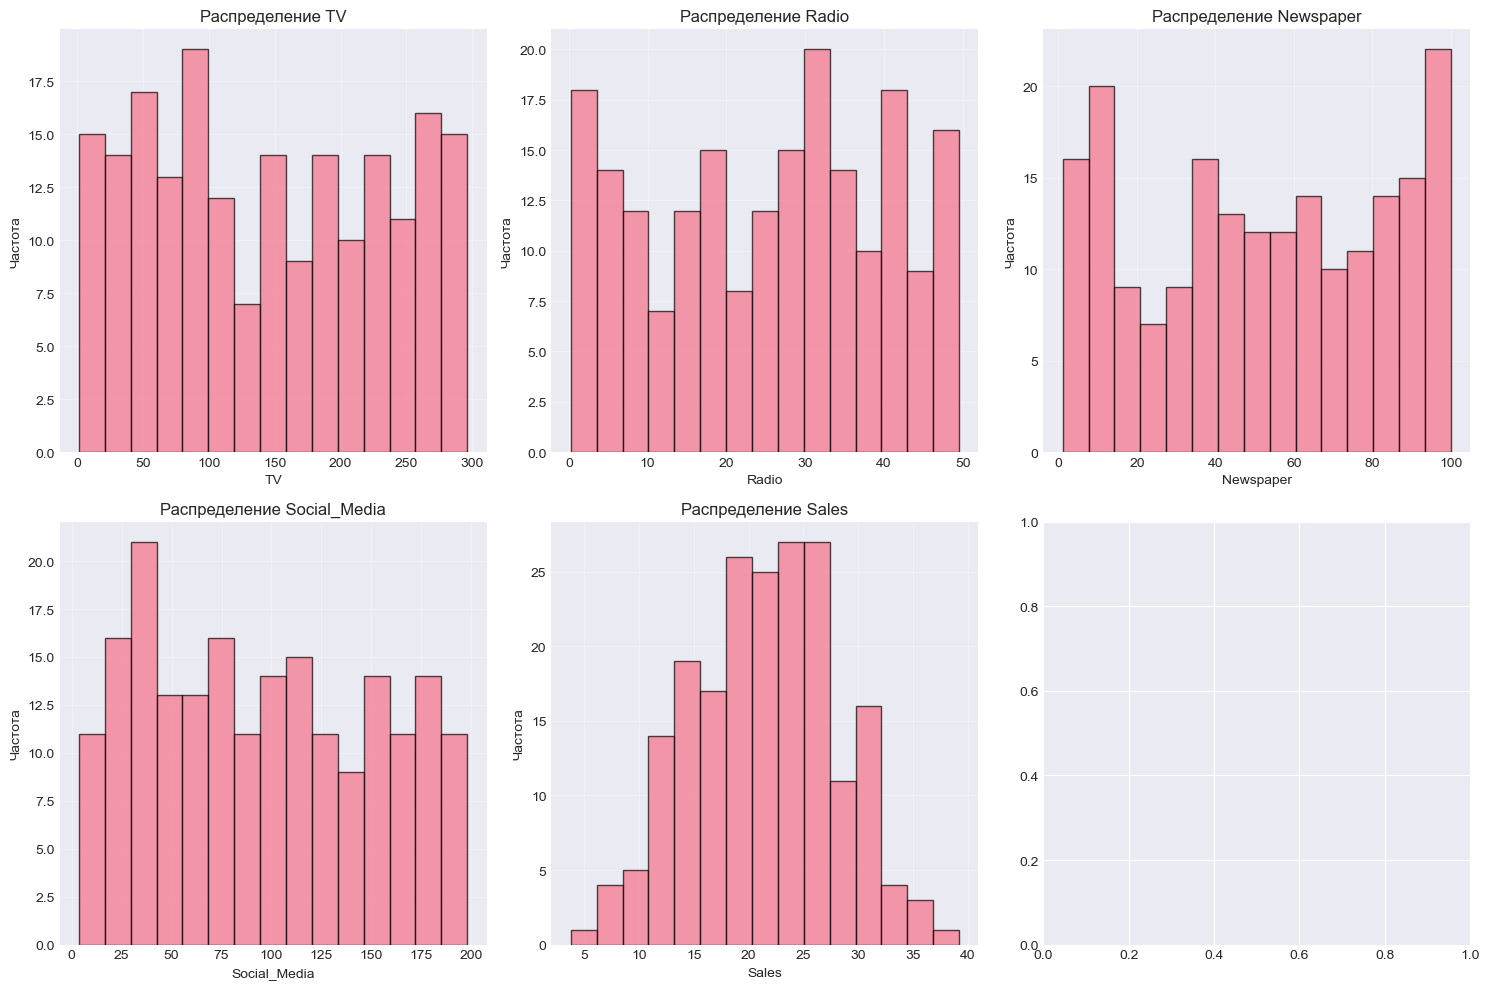

In [9]:
# Визуализация распределения признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

columns = df_multiple.columns
for i, col in enumerate(columns):
    axes[i].hist(df_multiple[col], bins=15, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].set_title(f'Распределение {col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

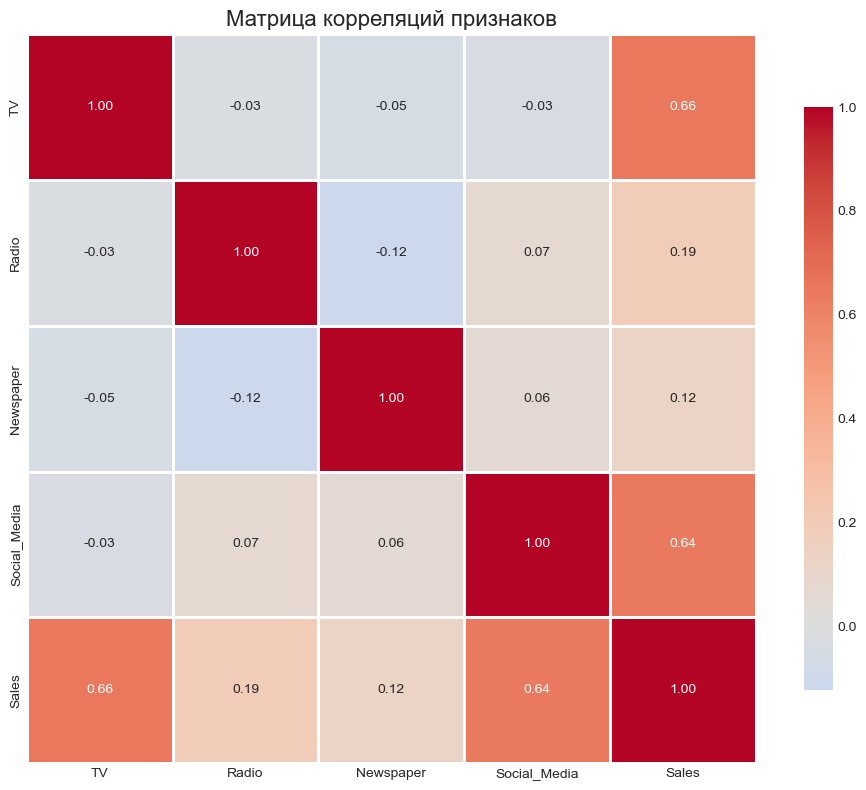

📊 Корреляция признаков с целевой переменной (Sales):
Sales           1.000000
TV              0.655357
Social_Media    0.642352
Radio           0.192818
Newspaper       0.117650


In [10]:
# Матрица корреляций
corr_matrix = df_multiple.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f')
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

print("📊 Корреляция признаков с целевой переменной (Sales):")
corr_with_target = corr_matrix['Sales'].sort_values(ascending=False)
print(corr_with_target.to_string())

In [11]:
# Определим разные комбинации признаков для экспериментов
feature_combinations = {
    'Модель 1 (только TV)': ['TV'],
    'Модель 2 (TV + Radio)': ['TV', 'Radio'],
    'Модель 3 (все традиционные)': ['TV', 'Radio', 'Newspaper'],
    'Модель 4 (TV + Radio + Social)': ['TV', 'Radio', 'Social_Media'],
    'Модель 5 (Radio + Social)': ['Radio', 'Social_Media'],
    'Модель 6 (все признаки)': ['TV', 'Radio', 'Newspaper', 'Social_Media']
}

print("📋 Комбинации признаков для экспериментов:")
for model_name, features in feature_combinations.items():
    print(f"  {model_name}: {features}")

📋 Комбинации признаков для экспериментов:
  Модель 1 (только TV): ['TV']
  Модель 2 (TV + Radio): ['TV', 'Radio']
  Модель 3 (все традиционные): ['TV', 'Radio', 'Newspaper']
  Модель 4 (TV + Radio + Social): ['TV', 'Radio', 'Social_Media']
  Модель 5 (Radio + Social): ['Radio', 'Social_Media']
  Модель 6 (все признаки): ['TV', 'Radio', 'Newspaper', 'Social_Media']


In [12]:
# Оценка всех моделей
results = []

for model_name, features in feature_combinations.items():
    print(f"\n{'='*50}")
    print(f"🏗️  Построение {model_name}")
    print(f"📋 Признаки: {features}")
    
    X = df_multiple[features]
    y = df_multiple['Sales']
    
    metrics = evaluate_model(X, y, model_name)
    results.append(metrics)
    
    print(f"📊 Коэффициенты: {[f'{c:.4f}' for c in metrics['coefficients']]}")
    print(f"📊 Intercept: {metrics['intercept']:.4f}")
    print(f"📊 R² (тест): {metrics['r2_test']:.4f}")
    print(f"📊 RMSE (тест): {metrics['rmse_test']:.4f}")


🏗️  Построение Модель 1 (только TV)
📋 Признаки: ['TV']
📊 Коэффициенты: ['0.0502']
📊 Intercept: 13.9842
📊 R² (тест): 0.3208
📊 RMSE (тест): 5.8246

🏗️  Построение Модель 2 (TV + Radio)
📋 Признаки: ['TV', 'Radio']
📊 Коэффициенты: ['0.0507', '0.1039']
📊 Intercept: 11.3180
📊 R² (тест): 0.3285
📊 RMSE (тест): 5.7914

🏗️  Построение Модель 3 (все традиционные)
📋 Признаки: ['TV', 'Radio', 'Newspaper']
📊 Коэффициенты: ['0.0514', '0.1105', '0.0279']
📊 Intercept: 9.5767
📊 R² (тест): 0.3985
📊 RMSE (тест): 5.4816

🏗️  Построение Модель 4 (TV + Radio + Social)
📋 Признаки: ['TV', 'Radio', 'Social_Media']
📊 Коэффициенты: ['0.0508', '0.0740', '0.0769']
📊 Intercept: 4.8035
📊 R² (тест): 0.9205
📊 RMSE (тест): 1.9924

🏗️  Построение Модель 5 (Radio + Social)
📋 Признаки: ['Radio', 'Social_Media']
📊 Коэффициенты: ['0.0654', '0.0766']
📊 Intercept: 12.3979
📊 R² (тест): 0.4579
📊 RMSE (тест): 5.2035

🏗️  Построение Модель 6 (все признаки)
📋 Признаки: ['TV', 'Radio', 'Newspaper', 'Social_Media']
📊 Коэффициенты: [

In [13]:
# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

# Создаем упрощенную таблицу для сравнения
comparison_df = results_df[[
    'model_name', 'n_features', 'r2_train', 'r2_test', 
    'rmse_train', 'rmse_test'
]].copy()

print("\n" + "="*80)
print("📊 СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ")
print("="*80)
print(comparison_df.round(4).to_string(index=False))


📊 СРАВНЕНИЕ РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ
                    model_name  n_features  r2_train  r2_test  rmse_train  rmse_test
          Модель 1 (только TV)           1    0.4555   0.3208      4.8385     5.8246
         Модель 2 (TV + Radio)           2    0.5107   0.3285      4.5866     5.7914
   Модель 3 (все традиционные)           3    0.5273   0.3985      4.5082     5.4816
Модель 4 (TV + Radio + Social)           3    0.8905   0.9205      2.1695     1.9924
     Модель 5 (Radio + Social)           2    0.4231   0.4579      4.9803     5.2035
       Модель 6 (все признаки)           4    0.9091   0.9341      1.9771     1.8138


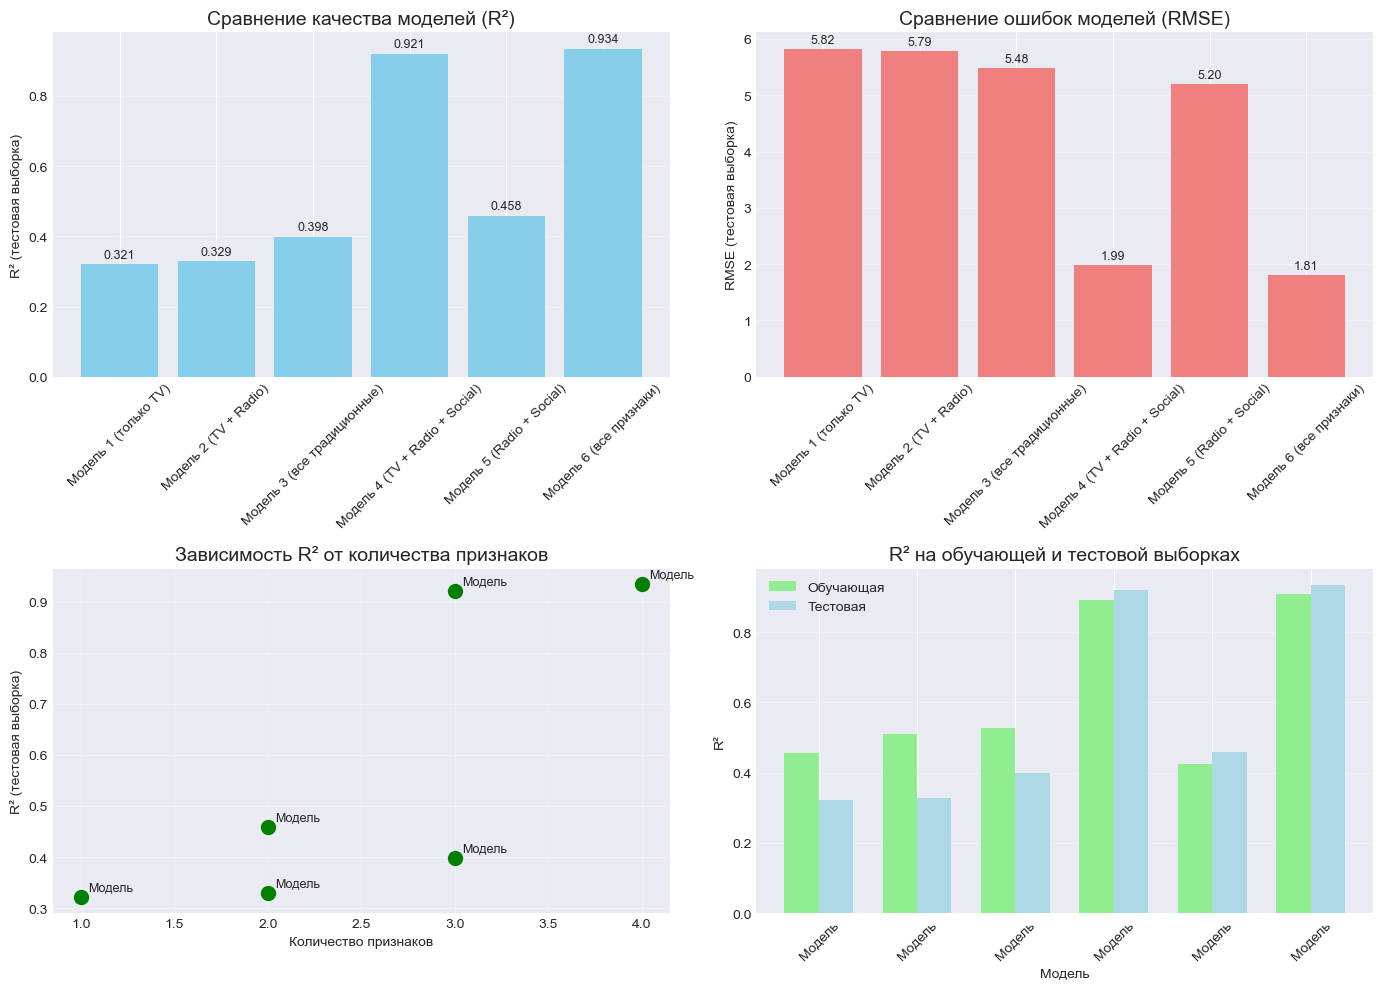

In [14]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Сравнение R² на тестовой выборке
models_names = results_df['model_name']
r2_scores = results_df['r2_test']

bars1 = axes[0, 0].bar(models_names, r2_scores, color='skyblue')
axes[0, 0].set_ylabel('R² (тестовая выборка)')
axes[0, 0].set_title('Сравнение качества моделей (R²)', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Сравнение RMSE на тестовой выборке
rmse_scores = results_df['rmse_test']
bars2 = axes[0, 1].bar(models_names, rmse_scores, color='lightcoral')
axes[0, 1].set_ylabel('RMSE (тестовая выборка)')
axes[0, 1].set_title('Сравнение ошибок моделей (RMSE)', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 3. Количество признаков vs R²
axes[1, 0].scatter(results_df['n_features'], results_df['r2_test'], s=100, color='green')
axes[1, 0].set_xlabel('Количество признаков')
axes[1, 0].set_ylabel('R² (тестовая выборка)')
axes[1, 0].set_title('Зависимость R² от количества признаков', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Добавление подписей точек
for i, row in results_df.iterrows():
    axes[1, 0].annotate(row['model_name'].split(' ')[0], 
                       (row['n_features'], row['r2_test']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9)

# 4. Сравнение R² на обучающей и тестовой выборках
x = np.arange(len(results_df))
width = 0.35
axes[1, 1].bar(x - width/2, results_df['r2_train'], width, label='Обучающая', color='lightgreen')
axes[1, 1].bar(x + width/2, results_df['r2_test'], width, label='Тестовая', color='lightblue')
axes[1, 1].set_xlabel('Модель')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('R² на обучающей и тестовой выборках', fontsize=14)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([m.split(' ')[0] for m in models_names], rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [15]:
# Выбор лучшей модели по R² на тестовой выборке
best_model_idx = results_df['r2_test'].idxmax()
best_model = results_df.loc[best_model_idx]

print("\n" + "="*80)
print("🏆 ЛУЧШАЯ МОДЕЛЬ ПО КАЧЕСТВУ ПРОГНОЗИРОВАНИЯ")
print("="*80)
print(f"📋 Название модели: {best_model['model_name']}")
print(f"📋 Используемые признаки: {feature_combinations[best_model['model_name']]}")
print(f"📋 Количество признаков: {best_model['n_features']}")
print(f"📊 R² на тестовой выборке: {best_model['r2_test']:.4f}")
print(f"📊 RMSE на тестовой выборке: {best_model['rmse_test']:.4f}")
print(f"📊 MAE на тестовой выборке: {best_model['mae_test']:.4f}")


🏆 ЛУЧШАЯ МОДЕЛЬ ПО КАЧЕСТВУ ПРОГНОЗИРОВАНИЯ
📋 Название модели: Модель 6 (все признаки)
📋 Используемые признаки: ['TV', 'Radio', 'Newspaper', 'Social_Media']
📋 Количество признаков: 4
📊 R² на тестовой выборке: 0.9341
📊 RMSE на тестовой выборке: 1.8138
📊 MAE на тестовой выборке: 1.4746
